In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

In [3]:
df=pd.read_csv("/dataset.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [4]:
df['trans_date_trans_time'] =pd.to_datetime(df['trans_date_trans_time'])
df['hours']=df['trans_date_trans_time'].dt.hour
df['day']=df['trans_date_trans_time'].dt.day
df['month']=df['trans_date_trans_time'].dt.month


In [5]:
drop_columns = ['Unnamed: 0','trans_date_trans_time','first','last','street','city','state','zip','dob','job','trans_num']
df=df.drop(columns=drop_columns)
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hours,day,month
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495.0,1.325376e+09,36.011293,-82.048315,0.0,0,1,1
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149.0,1.325376e+09,49.159047,-118.186462,0.0,0,1,1
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154.0,1.325376e+09,43.150704,-112.154481,0.0,0,1,1
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939.0,1.325376e+09,47.034331,-112.561071,0.0,0,1,1
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99.0,1.325376e+09,38.674999,-78.632459,0.0,0,1,1


In [6]:
cat_col = ['merchant', 'category', 'gender']
encoders = {}

for col in cat_col:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])


In [8]:
def haversine(lat1, lon1, lat2, lon2):
    return np.array([
        geodesic((a, b), (c, d)).km
        for a, b, c, d in zip(lat1, lon1, lat2, lon2)
    ])

# Drop rows with NaN values in the coordinate columns before calculating distance
df.dropna(subset=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [10]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hours,day,month,distance
0,2703186189652095,514,8,4.97,0,36.0788,-81.1781,3495.0,1.325376e+09,36.011293,-82.048315,0.0,0,1,1,78.773821
1,630423337322,241,4,107.23,0,48.8878,-118.2105,149.0,1.325376e+09,49.159047,-118.186462,0.0,0,1,1,30.216618
2,38859492057661,390,0,220.11,1,42.1808,-112.2620,4154.0,1.325376e+09,43.150704,-112.154481,0.0,0,1,1,108.102912
3,3534093764340240,360,2,45.00,1,46.2306,-112.1138,1939.0,1.325376e+09,47.034331,-112.561071,0.0,0,1,1,95.685115
4,375534208663984,297,9,41.96,1,38.4207,-79.4629,99.0,1.325376e+09,38.674999,-78.632459,0.0,0,1,1,77.702395


In [11]:
features = ['merchant','category','amt','cc_num','hours','day','month','gender','distance']

X = df[features]
y = df['is_fraud']

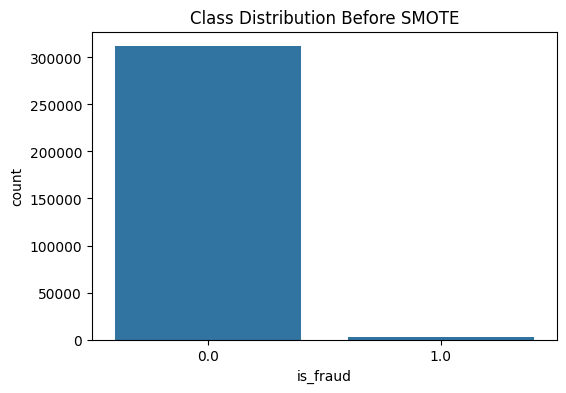

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resample, y_resample = smote.fit_resample(X, y)

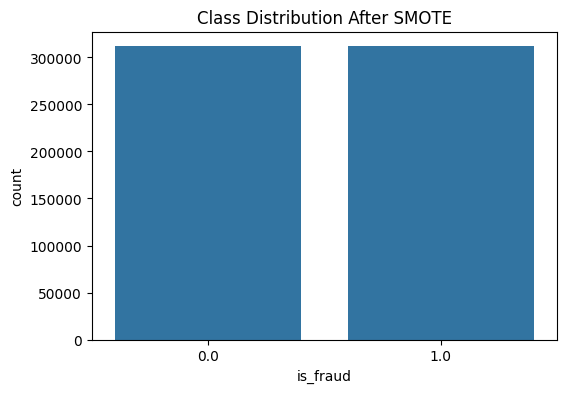

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resample)
plt.title("Class Distribution After SMOTE")
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resample, y_resample,
    test_size=0.2,
    random_state=42,
    stratify=y_resample
)

In [18]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    n_estimators=200,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 249463, number of negative: 249463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1098
[LightGBM] [Info] Number of data points in the train set: 498926, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=6, metric='auc',
               n_estimators=200, objective='binary', random_state=42)

In [19]:
y_pred =lgb_model.predict(X_test)

In [20]:
print("classification_report:\n ",classification_report(y_pred,y_test))
print("Roc AUC score:",roc_auc_score(y_test,y_pred))

classification_report:
                precision    recall  f1-score   support

         0.0       0.98      0.93      0.95     65385
         1.0       0.93      0.97      0.95     59347

    accuracy                           0.95    124732
   macro avg       0.95      0.95      0.95    124732
weighted avg       0.95      0.95      0.95    124732

Roc AUC score: 0.9517285059166853


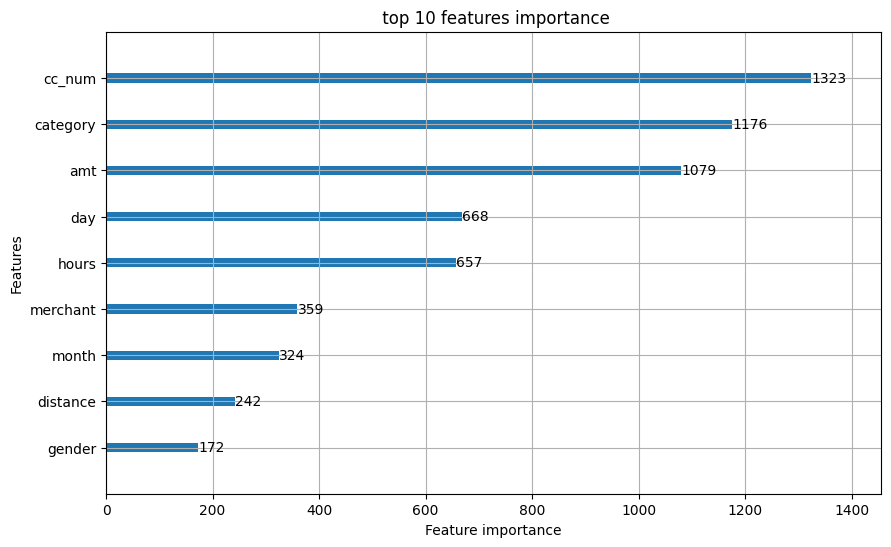

In [22]:
lgb.plot_importance(lgb_model ,max_num_features=10,importance_type='split',figsize=(10,6))
plt.title(" top 10 features importance")
plt.show()

In [24]:
fpr ,tpr ,thresholds = roc_curve(y_test,lgb_model.predict_proba(X_test)[:,1])
roc_auc=auc(fpr,tpr)

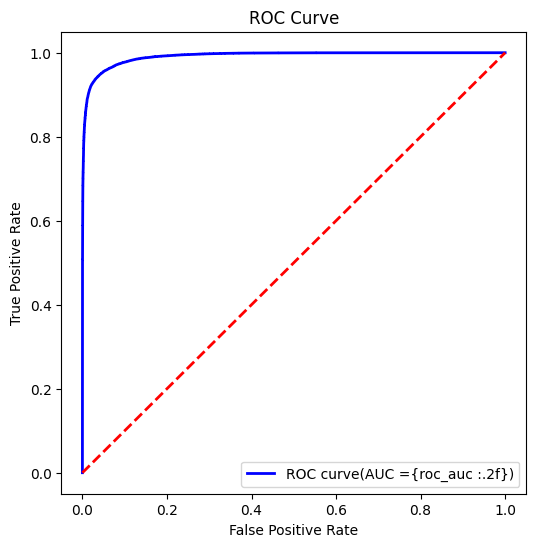

In [25]:
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,color='blue',lw=2,label='ROC curve(AUC ={roc_auc :.2f})')
plt.plot([0,1],[0,1],color='red',lw=2,linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()